# Visualization

- Models: 
    - mbert: https://huggingface.co/facebook/mbart-large-50-many-to-many-mmt
    - opus-mt: https://huggingface.co/Helsinki-NLP/opus-mt-zh-en

- Dataset: WMT-17, zh-en
    - https://huggingface.co/datasets/wmt/wmt17

- Metrics:
    - sacre-BLEU: https://github.com/mjpost/sacrebleu
    - CHRF: https://machinetranslate.org/chrF
    - Loss: Cross-Entropy Loss

In [1]:
import numpy as np
import random
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

## Load Experimental Data

In [7]:
def load_data(path: str) -> pd.DataFrame:
    df = pd.read_json(path, lines=True)

    df = pd.melt(df, id_vars=['src', 'tgt', 'num_train', 'num_test', 'num_val', 'reverse', 'model_name'], 
             value_vars=['eval_bleu', 'eval_chrf', 'eval_loss'],
             var_name='metric',
             value_name='value')
    return df

In [ ]:
df = load_data('./wmt17.jsonl')

In [12]:
df.head()

,src,tgt,num_train,num_test,num_val,reverse,model_name,metric,value
0,zh,en,90,20,9,False,mbert,eval_bleu,22.500740
1,zh,en,10,20,1,False,mbert,eval_bleu,22.104482
2,zh,en,30,20,3,False,mbert,eval_bleu,20.584039
3,zh,en,70,20,7,False,mbert,eval_bleu,24.130728
4,zh,en,30,20,3,False,mbert,eval_bleu,20.584039


## Inspect the Result Data

In [ ]:
df.src.unique(), df.tgt.unique() # Only zh-en.

(array(['zh'], dtype=object), array(['en'], dtype=object))

In [ ]:
df.num_test.unique() # num_test is fixed to 20.

array([20])

In [ ]:
sorted(df.num_train.unique()) # num_train is from 10 to 90.

[np.int64(10), np.int64(30), np.int64(50), np.int64(70), np.int64(90)]

In [ ]:
df.reverse.unique() # Only one direction: zh->en.

array([False])

In [ ]:
df.model_name.unique() # mBERT and OPUS-MT.

array(['mbert', 'opus-mt'], dtype=object)

In [20]:
df.columns

Index(['src', 'tgt', 'num_train', 'num_test', 'num_val', 'reverse',
       'model_name', 'metric', 'value'],
      dtype='object')

In [ ]:
df.metric.unique() # 'eval_bleu', 'eval_chrf', 'eval_loss'

array(['eval_bleu', 'eval_chrf', 'eval_loss'], dtype=object)

## Analyze the Results

Repeat time is 3.

Comparing two different models on three metrics.

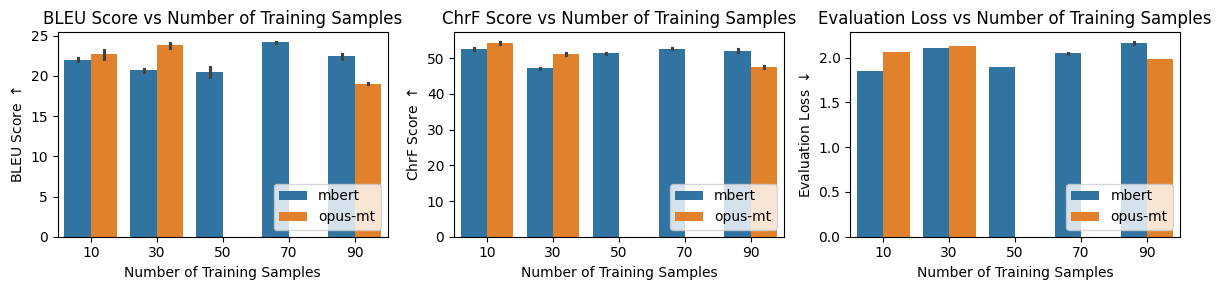

In [ ]:
plt.figure(figsize=(12, 3))
ax=plt.subplot(131)
sns.barplot(data=df[df.metric=='eval_bleu'], x='num_train', y='value', hue='model_name', errorbar='sd', ax=ax)
ax.set_title('BLEU Score vs Number of Training Samples')
ax.set_xlabel('Number of Training Samples')
ax.set_ylabel(r'BLEU Score $\uparrow$')
ax.legend().set_label(None)
ax=plt.subplot(132)
sns.barplot(data=df[df.metric=='eval_chrf'], x='num_train', y='value', hue='model_name', errorbar='sd', ax=ax)
ax.set_title('ChrF Score vs Number of Training Samples')
ax.set_xlabel('Number of Training Samples')
ax.set_ylabel(r'ChrF Score $\uparrow$')
ax.legend().set_label(None)
ax=plt.subplot(133)
sns.barplot(data=df[df.metric=='eval_loss'], x='num_train', y='value', hue='model_name', errorbar='sd', ax=ax)
ax.set_title('Evaluation Loss vs Number of Training Samples')
ax.set_xlabel('Number of Training Samples')
ax.set_ylabel(r'Evaluation Loss $\downarrow$')
ax.legend().set_label(None)
plt.suptitle('Performance of two models on three metrics with varying train sizes.')
plt.tight_layout()
plt.show()